# Group 10 Project Source Code
### March 13, 2026

## Additional Work: Allen Visual Behavior Neuropixels Dataset

### Preliminaries + Setup
We now move to the Allen Visual Behavior Neuropixels dataset, which also focuses on visual stimuli. In this dataset, mice do a visual change-detection task in which images are shown repeatedly and the mouse must respond when the image changes. The main thing that matters for this notebook is that the dataset includes both brain activity recorded from vision-related brain areas and trial outcomes showing whether the mouse correctly detected the change or missed it. Starting from the Allen session data, we will choose one session with enough recordings in the regions we care about, keep high-quality neurons, isolate hit and miss change trials, align the neural activity to the moment of image change, and organize the spike data into trial-by-trial activity over time. These processed signals will then be used for CEBRA analysis to test whether low-dimensional patterns of neural activity can distinguish successful vs unsuccessful detection. We also used the sklearn API from CEBRA.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorNeuropixelsProjectCache

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import balanced_accuracy_score, roc_auc_score

from cebra import CEBRA
import cebra.integrations.sklearn.metrics as cebra_metrics
cache_dir = "./allen_vbn_cache"
os.makedirs(cache_dir, exist_ok=True)

cache = VisualBehaviorNeuropixelsProjectCache.from_s3_cache(cache_dir=cache_dir)

processed_file = "./processed_vbn_session_1108334384.npz"

In [2]:
import torch

if torch.cuda.is_available():
    major, minor = torch.cuda.get_device_capability(0)
    if major >= 7:
        DEVICE = "cuda"
    else:
        DEVICE = "cpu"
else:
    DEVICE = "cpu"

print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))
    print("Compute capability:", torch.cuda.get_device_capability(0))

Using device: cpu
CUDA device: NVIDIA GeForce GTX 1080 Ti
Compute capability: (6, 1)


/home/adl007/.local/lib/python3.11/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 NVIDIA GeForce GTX 1080 Ti which is of cuda capability 6.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.0) - (12.0)
    
  queued_call()
/home/adl007/.local/lib/python3.11/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.6 following instructions at
    https://pytorch.org/get-started/locally/
    
  queued_call()
/home/adl007/.local/lib/python3.11/site-packages/torch/cuda/__init__.py:435: UserWarning: 
NVIDIA GeForce GTX 1080 Ti with CUDA capability sm_61 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_70 sm_75 sm_80 sm_86 sm_90 sm_100 sm_120.
If you want to use the NVIDIA GeForce GTX 1080 Ti GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  queued_ca

In [3]:
sessions = cache.get_ecephys_session_table()
print("Total sessions:", len(sessions))

units = cache.get_unit_table()
print("Total units:", len(units))

Total sessions: 103
Total units: 319013


### Selecting regions and sessions

We focus on visual cortical areas (VISp, VISl, VISrl, VISam, VISpm, VISal) and visual thalamic areas (LGd, LP), since these are the regions most directly relevant to visual change detection. We first inspect global unit counts and then identify sessions with sufficient neuron coverage in key regions, especially VISp and LGd.

In [31]:
target_regions = ['VISp', 'VISl', 'VISrl', 'VISam', 'VISpm', 'VISal', 'LGd', 'LP']
region_counts = units.loc[units['structure_acronym'].isin(target_regions), 'structure_acronym'].value_counts()

print(region_counts)
print("Total units in target regions:", region_counts.sum())

VISp     21567
VISpm    19772
VISl     19525
VISal    17442
VISam    16938
VISrl    15319
LP        5479
LGd       3866
Name: structure_acronym, dtype: int64
Total units in target regions: 119908


In [5]:
global_target_units = units[units['structure_acronym'].isin(target_regions)].copy()
session_region_counts = global_target_units.groupby(['ecephys_session_id', 'structure_acronym']).size().unstack(fill_value=0)

good_sessions = session_region_counts[
    (session_region_counts.get('VISp', 0) > 20) &
    (session_region_counts.get('LGd', 0) > 20)
]

print("Sessions meeting VISp/LGd threshold:", len(good_sessions))

Sessions meeting VISp/LGd threshold: 57


In [6]:
selected_sessions = [1108334384, 1087723305, 1043752325]

session = cache.get_ecephys_session(ecephys_session_id=selected_sessions[0])

/home/adl007/.local/lib/python3.11/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.6.0-alpha, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


### Define the behavioral comparison

We restrict the analysis to image-change trials labeled as **hit** or **miss**. This allows us to answer our question: Can population activity distinguish changes that were successfully detected from those that were missed?

In [32]:
trials = session.trials
print("Total trials:", len(trials))
print(trials[['hit', 'miss', 'false_alarm', 'correct_reject']].sum())

Total trials: 607
hit               108
miss              172
false_alarm         2
correct_reject     38
dtype: int64


### Construct trial-aligned neural features

We keep good-quality units from the selected visual/thalamic regions and convert raw spike times into a firing-rate tensor aligned to image change:

(trials, units, time bins)

This is the core neural representation used for CEBRA.

In [9]:
session_units = session.get_units()
print("Total units in this session:", len(session_units))

Total units in this session: 1846


In [10]:
unit_regions = units[['structure_acronym']].copy()
session_units_with_regions = session_units.join(unit_regions, how='left')
target_regions = ['VISp', 'VISl', 'VISrl', 'VISam', 'VISpm', 'VISal', 'LGd', 'LP']
session_units_filtered = session_units_with_regions[
    (session_units_with_regions['quality'] == 'good') &
    (session_units_with_regions['structure_acronym'].isin(target_regions))
].copy()

print(f"Good units in target regions: {len(session_units_filtered)}")
print(session_units_filtered['structure_acronym'].value_counts())

Good units in target regions: 1072
VISp     200
VISpm    165
VISrl    149
VISal    145
VISl     133
LGd      108
VISam    106
LP        66
Name: structure_acronym, dtype: int64


#### Constructing trial-aligned neural features
Raw spike times are converted into a firing-rate tensor by aligning each neuron’s spikes to the image-change time and binning activity in 50 ms windows from -1.0 s to +1.0 s. The output has shape:

(trials, units, time bins)

This representation preserves both population structure across neurons and temporal structure around the behavioral event, making it suitable for downstream embedding and decoding analyses.

In [33]:
change_trials = trials[(trials['hit'] == True) | (trials['miss'] == True)].copy()
change_trials['outcome'] = change_trials['hit'].map({True: 'hit', False: 'miss'})

print(f"Change trials: {len(change_trials)}")
print(change_trials['outcome'].value_counts())
print(change_trials[['start_time', 'change_time_no_display_delay', 'outcome']].head())

Change trials: 280
miss    172
hit     108
Name: outcome, dtype: int64
           start_time  change_time_no_display_delay outcome
trials_id                                                  
9            75.29062                      79.79517    miss
10           84.29801                      88.05151     hit
11           92.55515                      99.31106     hit
13          106.81732                     111.32115     hit
15          116.57550                     123.33102     hit


In [12]:
bin_size = 0.05  
window_start = -1.0  
window_end = 1.0    
bins = np.arange(window_start, window_end + bin_size, bin_size)
n_bins = len(bins) - 1
spike_times = session.spike_times
unit_ids = session_units_filtered.index.values
change_times = change_trials['change_time_no_display_delay'].values
print(f"Building firing rate matrix: {len(change_trials)} trials x {len(unit_ids)} units x {n_bins} bins")

firing_rates = np.zeros((len(change_times), len(unit_ids), n_bins))

for i, ct in enumerate(change_times):
    if np.isnan(ct):
        continue
    for j, uid in enumerate(unit_ids):
        spikes = spike_times[uid]
       
        relative_spikes = spikes - ct
        counts, _ = np.histogram(relative_spikes, bins=bins)
        firing_rates[i, j, :] = counts / bin_size  

print(f"Firing rate matrix shape: {firing_rates.shape}")
print(f"(trials, units, time_bins)")

Building firing rate matrix: 280 trials x 1072 units x 40 bins
Firing rate matrix shape: (280, 1072, 40)
(trials, units, time_bins)


In [13]:
trial_labels = change_trials["outcome"].values
trial_labels_binary = change_trials["hit"].values.astype(int)
brain_regions = session_units_filtered["structure_acronym"].values
bin_centers = bins[:-1] + bin_size / 2

In [14]:
np.savez(
    processed_file,
    firing_rates=firing_rates,
    trial_labels=trial_labels,
    trial_labels_binary=trial_labels_binary,
    brain_regions=brain_regions,
    unit_ids=unit_ids,
    bin_centers=bin_centers,
    bin_size=np.array(bin_size),
)
print(f"Saved to {processed_file}")

Saved to ./processed_vbn_session_1108334384.npz


In [15]:
data = np.load(processed_file, allow_pickle=True)
print("Saved keys:", data.files)
print("firing_rates shape:", data["firing_rates"].shape)

Saved keys: ['firing_rates', 'trial_labels', 'trial_labels_binary', 'brain_regions', 'unit_ids', 'bin_centers', 'bin_size']
firing_rates shape: (280, 1072, 40)


### Visualization of the processed dataset

Before using CEBRA, we visually inspect the data to confirm hit/miss, region coverage, and average firing dynamics are reasonable

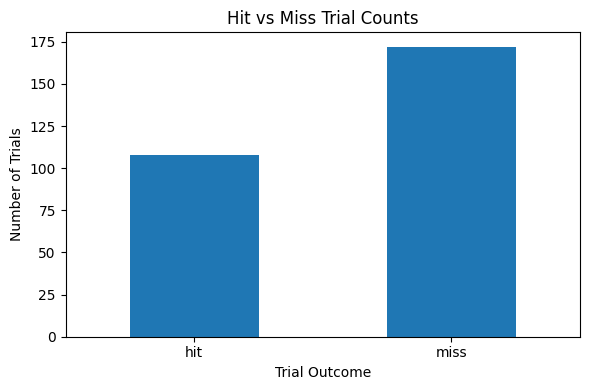

In [16]:
trial_count_df = pd.Series(trial_labels).value_counts().reindex(["hit", "miss"])

plt.figure(figsize=(6, 4))
trial_count_df.plot(kind="bar")
plt.title("Hit vs Miss Trial Counts")
plt.xlabel("Trial Outcome")
plt.ylabel("Number of Trials")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

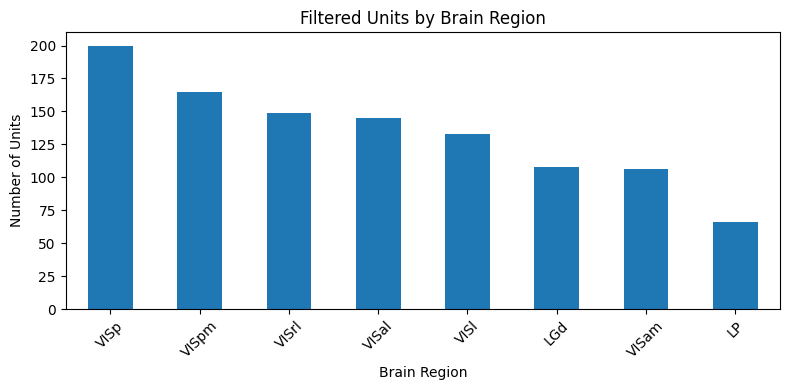

In [17]:
region_count_df = pd.Series(brain_regions).value_counts()

plt.figure(figsize=(8, 4))
region_count_df.plot(kind="bar")
plt.title("Filtered Units by Brain Region")
plt.xlabel("Brain Region")
plt.ylabel("Number of Units")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

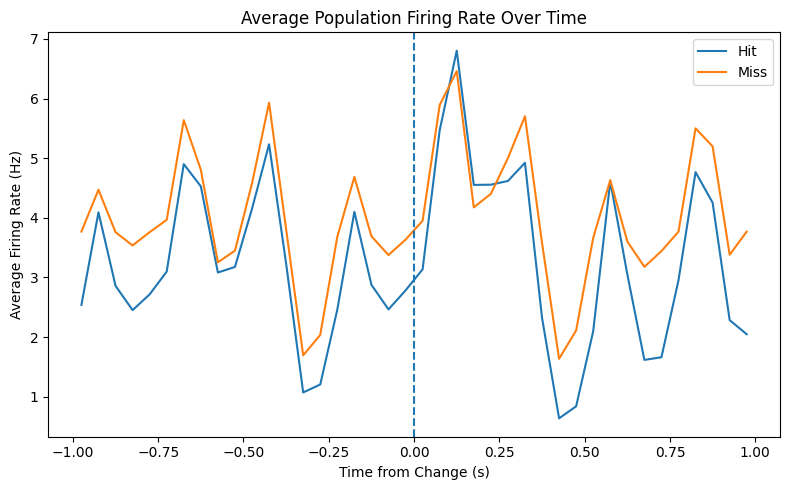

In [18]:
hit_mask = trial_labels == "hit"
miss_mask = trial_labels == "miss"

hit_mean = firing_rates[hit_mask].mean(axis=(0, 1))
miss_mean = firing_rates[miss_mask].mean(axis=(0, 1))

plt.figure(figsize=(8, 5))
plt.plot(bin_centers, hit_mean, label="Hit")
plt.plot(bin_centers, miss_mean, label="Miss")
plt.axvline(0, linestyle="--")
plt.title("Average Population Firing Rate Over Time")
plt.xlabel("Time from Change (s)")
plt.ylabel("Average Firing Rate (Hz)")
plt.legend()
plt.tight_layout()
plt.show()

### Preparation for CEBRA

The official CEBRA demo trains on a sample-by-feature neural matrix. Here we do the same by selecting a primary time window, splitting trials into train/validation/test sets, and reshaping trial × unit × time into bin-level samples.

In [19]:
print("firing_rates:", firing_rates.shape)
print("trial_labels_binary:", trial_labels_binary.shape)
print("hit count:", trial_labels_binary.sum())
print("miss count:", (trial_labels_binary == 0).sum())
print("brain regions:", {r: (brain_regions == r).sum() for r in np.unique(brain_regions)})
print("time bins:", bin_centers[:5], "...", bin_centers[-5:])

firing_rates: (280, 1072, 40)
trial_labels_binary: (280,)
hit count: 108
miss count: 172
brain regions: {'LGd': 108, 'LP': 66, 'VISal': 145, 'VISam': 106, 'VISl': 133, 'VISp': 200, 'VISpm': 165, 'VISrl': 149}
time bins: [-0.975 -0.925 -0.875 -0.825 -0.775] ... [0.775 0.825 0.875 0.925 0.975]


In [20]:
data = np.load(processed_file, allow_pickle=True)

firing_rates = data["firing_rates"]              # (trials, units, bins)
trial_labels_binary = data["trial_labels_binary"].astype(int)
trial_labels = data["trial_labels"].astype(str)
brain_regions = data["brain_regions"].astype(str)
bin_centers = data["bin_centers"]

print("firing_rates:", firing_rates.shape)
print("hits:", int(trial_labels_binary.sum()))
print("misses:", int((trial_labels_binary == 0).sum()))

firing_rates: (280, 1072, 40)
hits: 108
misses: 172


### Primary Analysis Window

We focused on an early window from -0.20 s to +0.15 s around the image change. This window is intended to emphasize sensory and early decision-related activity close to the time of the change, while reducing the chance that decoding is driven mainly by later response-related or motor activity. In the Allen Visual Behavior task, mice respond to image changes within a 750 ms response window, so concentrating on this earlier period provides a more conservative test of whether neural activity predicts successful detection.

In [21]:
time_mask = (bin_centers >= -0.20) & (bin_centers <= 0.15)
sel_times = bin_centers[time_mask]

X_trials = firing_rates[:, :, time_mask]   # (trials, units, selected_bins)
y_trials = trial_labels_binary.copy()

print("Selected window:", sel_times[0], "to", sel_times[-1], "sec")
print("X_trials shape:", X_trials.shape)

Selected window: -0.1749999999999993 to 0.12500000000000097 sec
X_trials shape: (280, 1072, 7)


### Helper Functions

We were forced to adapt from the CEBRA since our data is a trial x neuron x time-bin while CEBRA expects a 2D sample x feature matrix. We used chatGPT to help write the conversions since we were aware of this issue. 

Essentially, **make_bin_level_dataset takes** breaks each trial into smaller moment-by-moment snapshots of neural activity and keeps track of both the time within the trial and whether that trial was a hit or a miss. **average_bins_back_to_trials** combines those moment-by-moment CEBRA outputs back into one summary for each trial. **choose_best_k** finds the best k value for the k-nearest neighbors decoder by checking which one performs best on validation data.

In [34]:
def make_bin_level_dataset(X_trials, y_trials, times):
    n_trials, n_units, n_bins = X_trials.shape
    X_bins = X_trials.transpose(0, 2, 1).reshape(n_trials * n_bins, n_units)
    y_bins = np.repeat(y_trials, n_bins)
    time_idx = np.tile(times, n_trials).reshape(-1, 1)
    return X_bins, time_idx, y_bins

def average_bins_back_to_trials(Z_bins, n_trials, n_bins):
    """
    Convert embedding from:
      (n_trials*n_bins, embed_dim)
    back to:
      (n_trials, embed_dim)
    by averaging over bins within each trial.
    """
    return Z_bins.reshape(n_trials, n_bins, -1).mean(axis=1)

def choose_best_k(X_train, y_train, X_val, y_val, k_grid=(1, 3, 5, 7, 9, 15)):
    best_k = None
    best_score = -np.inf
    for k in k_grid:
        clf = KNeighborsClassifier(n_neighbors=k, metric="cosine")
        clf.fit(X_train, y_train)
        pred = clf.predict(X_val)
        score = balanced_accuracy_score(y_val, pred)
        if score > best_score:
            best_score = score
            best_k = k
    return best_k, best_score

### Train/Validation/Test Split

All splits are performed at the trial level rather than the time-bin level. The validation split is used to tune the downstream k-nearest-neighbors decoder, while the test split is held out for final evaluation. This is a structural change from the official demo, where the split is based on repeated movie presentations rather than individual behavioral trials. We had to make this change because of the data that we are working with.

In [23]:
outer = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=0)
trainval_idx, test_idx = next(outer.split(np.zeros(len(y_trials)), y_trials))

X_trainval_trials = X_trials[trainval_idx]
X_test_trials = X_trials[test_idx]
y_trainval = y_trials[trainval_idx]
y_test = y_trials[test_idx]

inner = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=0)  # 0.25 of 0.8 = 0.2 total
train_idx_rel, val_idx_rel = next(inner.split(np.zeros(len(y_trainval)), y_trainval))

X_train_trials = X_trainval_trials[train_idx_rel]
X_val_trials = X_trainval_trials[val_idx_rel]
y_train = y_trainval[train_idx_rel]
y_val = y_trainval[val_idx_rel]

print("Train trials:", len(y_train))
print("Val trials:", len(y_val))
print("Test trials:", len(y_test))

Train trials: 168
Val trials: 56
Test trials: 56


In [24]:
X_train_bins, train_time_idx, y_train_bins = make_bin_level_dataset(X_train_trials, y_train, sel_times)
X_val_bins, val_time_idx, y_val_bins = make_bin_level_dataset(X_val_trials, y_val, sel_times)
X_test_bins, test_time_idx, y_test_bins = make_bin_level_dataset(X_test_trials, y_test, sel_times)

# z-score each neuron using TRAIN only
scaler = StandardScaler(with_mean=True, with_std=True)
X_train_bins_z = scaler.fit_transform(X_train_bins)
X_val_bins_z = scaler.transform(X_val_bins)
X_test_bins_z = scaler.transform(X_test_bins)

print("Bin-level train shape:", X_train_bins_z.shape)
print("Bin-level val shape:", X_val_bins_z.shape)
print("Bin-level test shape:", X_test_bins_z.shape)

Bin-level train shape: (1176, 1072)
Bin-level val shape: (392, 1072)
Bin-level test shape: (392, 1072)


### Baseline Decoders
Before fitting CEBRA, we evaluate two simpler baselines:
- raw mean firing-rate features + kNN
- PCA-reduced features + kNN

These baselines test whether CEBRA provides useful structure beyond straightforward neural representations. They also make the analysis more comparable to the demo workflow, which evaluates embeddings by how well they support downstream decoding on held-out data. 

In [25]:
# Raw baseline: average over bins within each trial
raw_train = X_train_trials.mean(axis=2)
raw_val = X_val_trials.mean(axis=2)
raw_test = X_test_trials.mean(axis=2)

raw_scaler = StandardScaler()
raw_train_z = raw_scaler.fit_transform(raw_train)
raw_val_z = raw_scaler.transform(raw_val)
raw_test_z = raw_scaler.transform(raw_test)

best_k_raw, _ = choose_best_k(raw_train_z, y_train, raw_val_z, y_val)
clf_raw = KNeighborsClassifier(n_neighbors=best_k_raw, metric="cosine")
clf_raw.fit(raw_train_z, y_train)
pred_raw = clf_raw.predict(raw_test_z)
prob_raw = clf_raw.predict_proba(raw_test_z)[:, 1]

# PCA baseline
pca = PCA(n_components=min(8, raw_train_z.shape[1]))
pca_train = pca.fit_transform(raw_train_z)
pca_val = pca.transform(raw_val_z)
pca_test = pca.transform(raw_test_z)

best_k_pca, _ = choose_best_k(pca_train, y_train, pca_val, y_val)
clf_pca = KNeighborsClassifier(n_neighbors=best_k_pca, metric="cosine")
clf_pca.fit(pca_train, y_train)
pred_pca = clf_pca.predict(pca_test)
prob_pca = clf_pca.predict_proba(pca_test)[:, 1]

print("Raw baseline balanced acc:", balanced_accuracy_score(y_test, pred_raw))
print("PCA baseline balanced acc:", balanced_accuracy_score(y_test, pred_pca))

Raw baseline balanced acc: 0.8275401069518716
PCA baseline balanced acc: 0.9398395721925134


### Training the data

As in the official Allen demo we train:
- CEBRA-Time: time structure only (control)
- CEBRA-Behavior: time + hit/miss labels (includes behavior that indicates hit/miss for training)

In [28]:
rng = np.random.default_rng(0)
y_train_bins_shuffled = rng.permutation(y_train_bins)

cebra_behavior_shuffle = CEBRA(
    model_architecture="offset10-model",
    batch_size=256,
    learning_rate=3e-4,
    temperature=1.0,
    output_dimension=8,
    max_iterations=1500,
    distance="cosine",
    conditional="time_delta",
    time_offsets=5,
    device=DEVICE,
    verbose=True,
)

cebra_behavior_shuffle.fit(X_train_bins_z, y_train_bins_shuffled)

Z_train_shuf = cebra_behavior_shuffle.transform(X_train_bins_z)
Z_val_shuf = cebra_behavior_shuffle.transform(X_val_bins_z)
Z_test_shuf = cebra_behavior_shuffle.transform(X_test_bins_z)

Z_train_shuf_trial = average_bins_back_to_trials(Z_train_shuf, n_train_trials, n_sel_bins)
Z_val_shuf_trial = average_bins_back_to_trials(Z_val_shuf, n_val_trials, n_sel_bins)
Z_test_shuf_trial = average_bins_back_to_trials(Z_test_shuf, n_test_trials, n_sel_bins)

best_k_shuf, _ = choose_best_k(Z_train_shuf_trial, y_train, Z_val_shuf_trial, y_val)
clf_shuf = KNeighborsClassifier(n_neighbors=best_k_shuf, metric="cosine")
clf_shuf.fit(Z_train_shuf_trial, y_train)

pred_shuf = clf_shuf.predict(Z_test_shuf_trial)
prob_shuf = clf_shuf.predict_proba(Z_test_shuf_trial)[:, 1]

print("Shuffled-label CEBRA balanced acc:", balanced_accuracy_score(y_test, pred_shuf))
print("Shuffled-label CEBRA AUROC:", roc_auc_score(y_test, prob_shuf))

pos: -0.9746 neg:  5.9967 total:  5.0220 temperature:  1.0000: 100%|██████████| 1500/1500 [02:47<00:00,  8.98it/s]


Shuffled-label CEBRA balanced acc: 0.4385026737967914
Shuffled-label CEBRA AUROC: 0.4385026737967914


### Evaluating model

This section mirrors the evaluation phase of the official demo by comparing model outputs to see what model (or none) is the most successful at identifying hits vs misses

In [29]:
results_df = pd.DataFrame([
    {
        "model": "Raw + kNN",
        "balanced_accuracy": balanced_accuracy_score(y_test, pred_raw),
        "auroc": roc_auc_score(y_test, prob_raw),
    },
    {
        "model": "PCA + kNN",
        "balanced_accuracy": balanced_accuracy_score(y_test, pred_pca),
        "auroc": roc_auc_score(y_test, prob_pca),
    },
    {
        "model": "CEBRA-Time + kNN",
        "balanced_accuracy": balanced_accuracy_score(y_test, pred_time),
        "auroc": roc_auc_score(y_test, prob_time),
    },
    {
        "model": "CEBRA-Behavior + kNN",
        "balanced_accuracy": balanced_accuracy_score(y_test, pred_beh),
        "auroc": roc_auc_score(y_test, prob_beh),
    },
    {
        "model": "CEBRA-Behavior shuffled + kNN",
        "balanced_accuracy": balanced_accuracy_score(y_test, pred_shuf),
        "auroc": roc_auc_score(y_test, prob_shuf),
    },
])

display(results_df)

,model,balanced_accuracy,auroc
0,Raw + kNN,0.827540,0.903743
1,PCA + kNN,0.939840,0.953877
2,CEBRA-Time + kNN,0.513369,0.513369
3,CEBRA-Behavior + kNN,0.879679,0.879679
4,CEBRA-Behavior shuffled + kNN,0.438503,0.438503


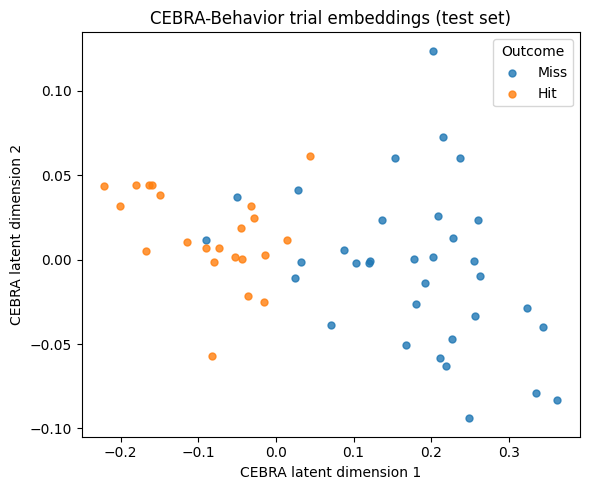

In [37]:
hit_idx = y_test == 1
miss_idx = y_test == 0

plt.figure(figsize=(6, 5))
plt.scatter(
    Z_test_beh_trial[miss_idx, 0],
    Z_test_beh_trial[miss_idx, 1],
    s=25,
    alpha=0.8,
    label="Miss"
)
plt.scatter(
    Z_test_beh_trial[hit_idx, 0],
    Z_test_beh_trial[hit_idx, 1],
    s=25,
    alpha=0.8,
    label="Hit"
)

plt.title("CEBRA-Behavior trial embeddings (test set)")
plt.xlabel("CEBRA latent dimension 1")
plt.ylabel("CEBRA latent dimension 2")
plt.legend(title="Outcome")
plt.tight_layout()
plt.show()

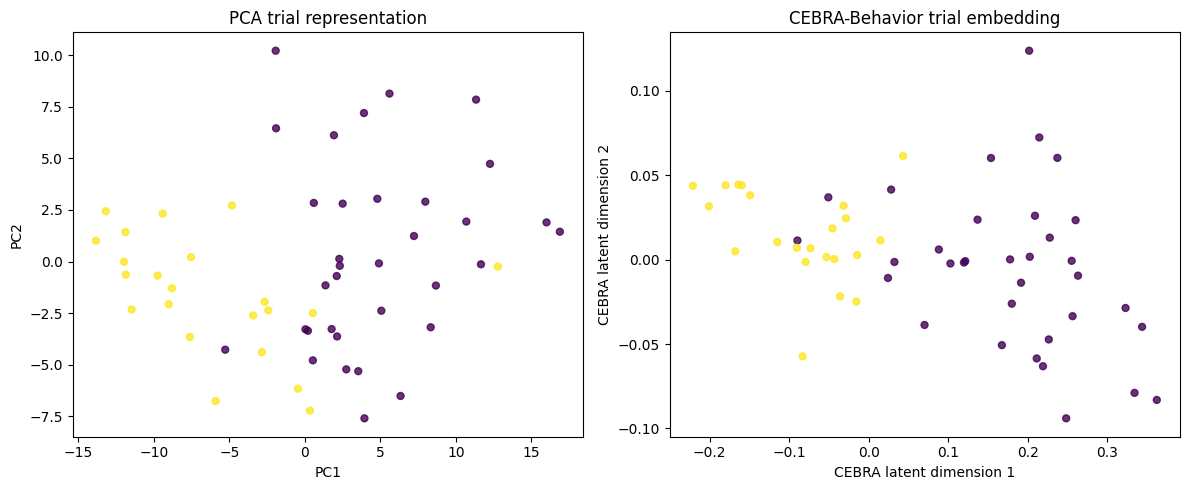

In [40]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(pca_test[:, 0], pca_test[:, 1], c=y_test, alpha=0.8, s=25)
plt.title("PCA trial representation")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.subplot(1, 2, 2)
plt.scatter(Z_test_beh_trial[:, 0], Z_test_beh_trial[:, 1], c=y_test, alpha=0.8, s=25)
plt.title("CEBRA-Behavior trial embedding")
plt.xlabel("CEBRA latent dimension 1")
plt.ylabel("CEBRA latent dimension 2")

plt.tight_layout()
plt.show()